In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import crystalball

np.random.seed(1234)

## Aim of this exercise
1. Understand the idea of CIs using Neyman construction
2. Check the CIs for Symmetric response, tail on one side and (3) wider distribution on one side with double sided gaussian
3. What do you notice in all the 3 cases?
4. What coverage do you see?


In [2]:
m_true = 125.0
#response = "gaus"
#response = "cb"
response = "dcb"

In [3]:
### Gaussian detector response
def gaussian_response(mtrue, sigma, N):
    return np.random.normal(mtrue, sigma, N)

In [4]:
### Crystal Ball detector response
def crystalball_response(mtrue, sigma, alpha=1.5, n=3, N=100):

    x = crystalball.rvs(beta=alpha,
                        m=n,
                        loc=mtrue,
                        scale=sigma,
                        size=N)

    return x

In [5]:
### Two sided asymmetric gaussian
def cruijff_response(mtrue,
                     sigmaL,
                     sigmaR,
                     N):

    x = np.random.randn(N)

    reco = np.empty(N)

    mask = x<0

    reco[mask] = mtrue + sigmaL*x[mask]

    reco[~mask] = mtrue + sigmaR*x[~mask]

    return reco

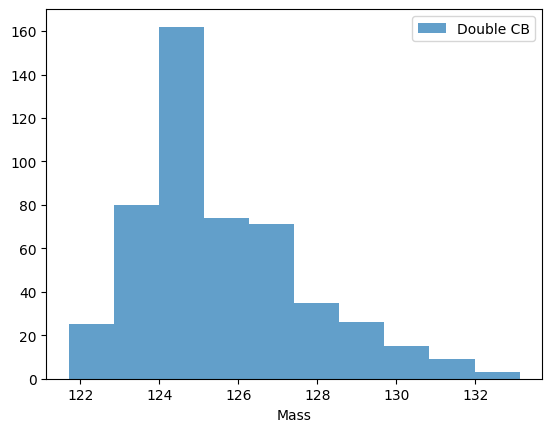

In [6]:
### Generate 500 pseudo experiment using Gaussian/CB or Cruijff and look at the Higgs mass.
Nevents = 500

sigma_detector = 1.3

### write the code here
gauss = gaussian_response(m_true, sigma_detector, Nevents)
cb = crystalball_response(m_true, sigma_detector, N=Nevents)
crf = cruijff_response(m_true, sigma_detector, 2*sigma_detector, N=Nevents)

#plt.hist(gauss, alpha=0.7, label="Gaussian")
#plt.hist(cb, alpha=0.5, label="Crystal Ball")
plt.hist(crf, alpha=0.7, label="Double CB")
plt.xlabel('Mass')
plt.legend()
plt.show()


In [7]:
### Now generate 5000 pseudoexperiments.
N=5000

crf = cruijff_response(m_true, sigma_detector, 2*sigma_detector, N=N)

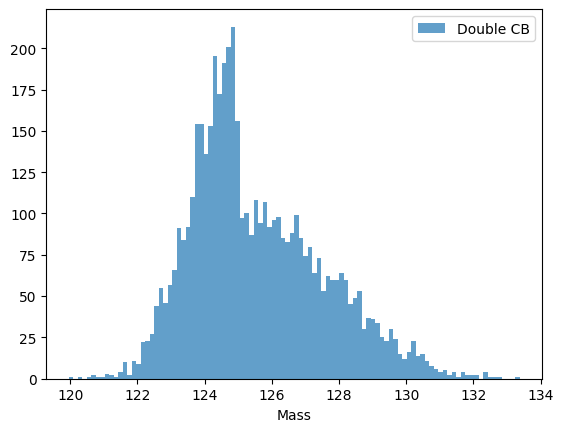

In [8]:
### plot the reconstructed Mass
counts, bins, _ = plt.hist(crf, alpha=0.7, label="Double CB", bins=100)
plt.xlabel('Mass')
plt.legend()
plt.show()

In [9]:
### Write the classical CI

lower = np.percentile(crf, 15.85)
higher = np.percentile(crf, 84.15)
print(lower)
print(higher)

123.73262467233776
127.72278151653664


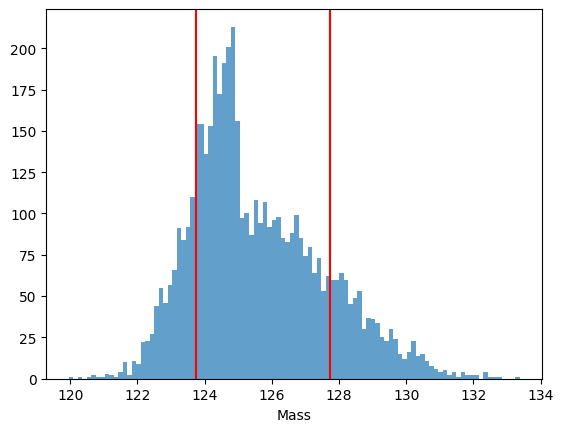

In [10]:
### plot the lines of CI on the histogram
plt.hist(crf, alpha=0.7, label="Double CB", bins=100)
plt.xlabel('Mass')
plt.axvline(lower, color='red')
plt.axvline(higher, color='red')
plt.show()

In [11]:
#Build Neyman belt: For each Hypothesised mass, generate the reconstructed mass: Consider generating
# Hypothesised masses from 110 to 150 GeV
## Check what happens if you generate from 124 to 127 (in terms of coverage probabiliy)

masses = {}
for m in range(110, 150, 1):
  m_reco = cruijff_response(m, sigma_detector, 2*sigma_detector, N=N)
  masses[m] = m_reco

In [13]:
lower=[]
upper=[]

In [14]:
# Belt construction: sample the distribution of the estimator
# at each true mass value.
# The estimator here is a single measurement (mhat = reco[0]),
# so we sample many single measurements from the response function.

trueMasses = range(110, 150, 1)
Ntoys_belt = 10000   # single measurements per belt point

### For each of the true mass Hypothesis
for mt in trueMasses:
    m_est = cruijff_response(mt, sigma_detector, 2*sigma_detector, N=Ntoys_belt)
    lower.append(np.percentile(m_est, 15.85))
    upper.append(np.percentile(m_est, 84.15))
### Write here

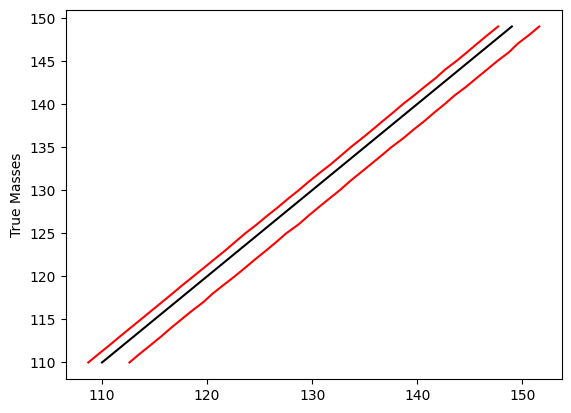

In [15]:
### plot Neyman belt and also plot the slope = 1 line to visualize whether the intervals are symmetric or asymmetric

plt.plot(lower, trueMasses, color='red')
plt.plot(upper, trueMasses, color='red')
plt.plot(trueMasses, trueMasses, color='black')
plt.ylabel('True Masses')
plt.show()

In [1]:
### invert the neyman belt to get the CI on mobs = 125 GeV


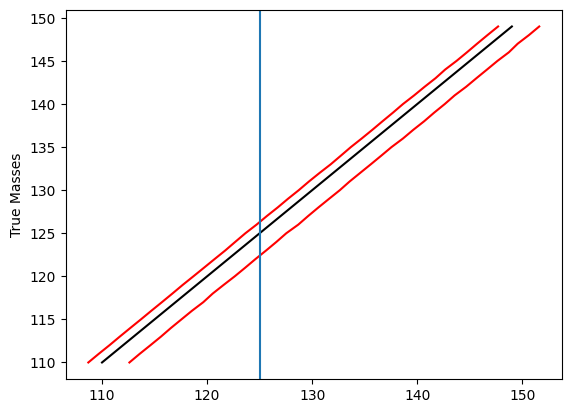

In [16]:
### plot that mobs = 125 GeV on the Neyman belt
plt.plot(lower, trueMasses, color='red')
plt.plot(upper, trueMasses, color='red')
plt.plot(trueMasses, trueMasses, color='black')
plt.axvline(125.0)
plt.ylabel('True Masses')
plt.show()

In [25]:
### coverage test
### Full Neyman coverage test
id = 0
for idx in range(len(lower)):
  print(idx)
  print(lower[idx])
  if lower[idx] < 125.0:
    id = idx

m_lower = (trueMasses[id + 1] - trueMasses[id])/(lower[id + 1] - lower[id])
c_lower = trueMasses[id] - (m_lower*lower[id])

trueMasses[id + 1]

0
108.69652422422392
1
109.68564883843166
2
110.70640302930164
3
111.68710167622734
4
112.68829385476651
5
113.69943476179084
6
114.69209009036484
7
115.7002086851122
8
116.69653039453864
9
117.67428245079026
10
118.69531915110214
11
119.70505968289086
12
120.71004068160566
13
121.72515816525184
14
122.6795689012267
15
123.64332163636628
16
124.70479979107171
17
125.68891241078359
18
126.72160095961743
19
127.69704906687
20
128.72279518279694
21
129.6849370805912
22
130.702111817374
23
131.75950114969152
24
132.7234043962894
25
133.67833060521343
26
134.71420820072044
27
135.718983041249
28
136.69341240952758
29
137.6866059206986
30
138.64188140677635
31
139.69857785646835
32
140.69642614585783
33
141.73999512136092
34
142.65318408699756
35
143.7321241296893
36
144.7252765790672
37
145.69111654686495
38
146.68029735896565
39
147.68992118961296


127